In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv("../data/womens_clothing_reviews.csv")  #   .. means: notebooks → go up → PROJECT → then open data

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [3]:
df.shape

(23486, 11)

In [4]:
df.columns


Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [6]:
df.isnull().sum()      # Data Cleaning because Datasets always contain missing values.


Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [7]:
df.head()


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [8]:
df.describe()

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


In [9]:
df = df.dropna(subset=["Review Text"])

In [10]:
df["Department Name"].fillna("Unknown", inplace=True)                     #  modify a temporary copy instead of the real dataframe.
df["Class Name"].fillna("Unknown", inplace=True)

C:\Users\smitd\AppData\Local\Temp\ipykernel_5524\3743033443.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Department Name"].fillna("Unknown", inplace=True)                     #  modify a temporary copy instead of the real dataframe.
C:\Users\smitd\AppData\Local\Temp\ipykernel_5524\3743033443.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

In [44]:
# Age Group creation using pd.cut() function to categorize ages into groups.



df["Age Group"] = pd.cut(
    df["Age"],
    bins=[18,25,35,45,60,100],
    labels=["18-25","26-35","36-45","46-60","60+"]
)

In [12]:
df[['Age','Age Group']].head()


,Age,Age Group
0,33,26-35
1,34,26-35
2,60,46-60
3,50,46-60
4,47,46-60


In [13]:
df['Age Group'].value_counts()

Age Group
36-45    7093
46-60    6484
26-35    5493
60+      2384
18-25    1183
Name: count, dtype: int64

<Axes: xlabel='Age Group'>

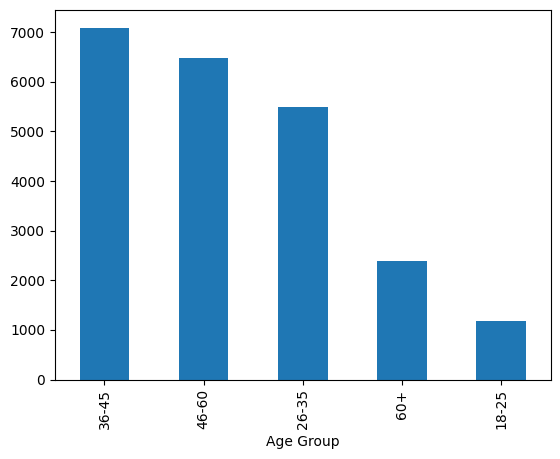

In [14]:
df['Age Group'].value_counts().plot(kind='bar')


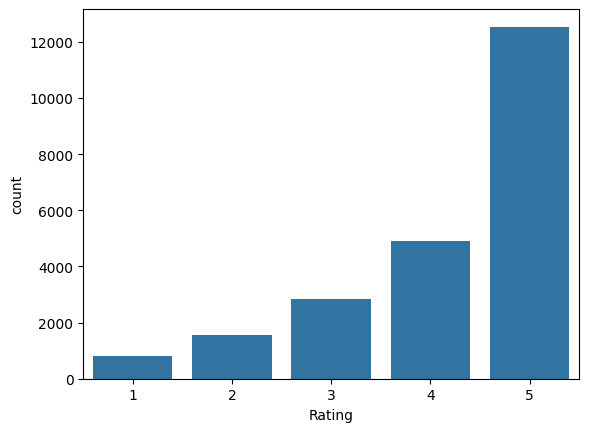

In [15]:
# Exploratory Data Analysis (EDA)
# Rating Distribution


import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Rating", data=df)
plt.show()

<Axes: xlabel='Department Name'>

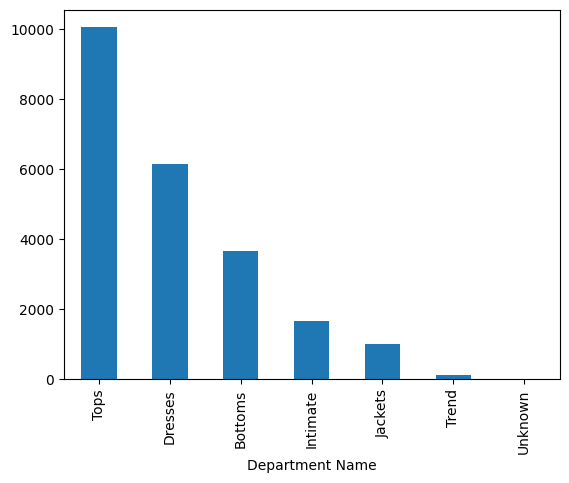

In [16]:
df["Department Name"].value_counts().plot(kind="bar")      # Reviews by Department

Sentiment Analysis  (NLP)

In [17]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [45]:
df["sentiment"] = df["Rating"].apply(
    lambda x: "Positive" if x >= 4 else "Negative"
)

In [18]:
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df["Sentiment Score"] = df["Review Text"].apply(get_sentiment)
df["Sentiment"] = df["Sentiment Score"].apply(
    lambda x: "Positive" if x>0 else "Negative"
)

In [19]:
df['Sentiment'].value_counts() 


Sentiment
Positive    21227
Negative     1414
Name: count, dtype: int64

<Axes: xlabel='Sentiment', ylabel='count'>

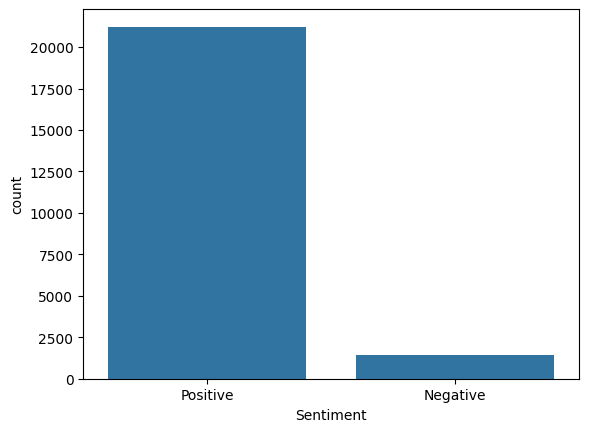

In [20]:
import seaborn as sns
sns.countplot(x='Sentiment', data=df)

In [21]:
df[['Review Text','Sentiment Score','Sentiment']].head()

,Review Text,Sentiment Score,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,0.633333,Positive
1,Love this dress! it's sooo pretty. i happene...,0.339583,Positive
2,I had such high hopes for this dress and reall...,0.073675,Positive
3,"I love, love, love this jumpsuit. it's fun, fl...",0.550000,Positive
4,This shirt is very flattering to all due to th...,0.512891,Positive


In [22]:
df[df['Sentiment']=='Negative']['Class Name'].value_counts()    #  Negative Reviews by Clothing Category

Class Name
Dresses       390
Knits         285
Blouses       157
Pants         104
Sweaters       84
Fine gauge     63
Jeans          59
Lounge         57
Jackets        49
Skirts         48
Outerwear      24
Swim           21
Shorts         16
Sleep          14
Trend          13
Layering       13
Legwear         9
Intimates       8
Name: count, dtype: int64

In [23]:
pd.crosstab(df["Age Group"], df["Sentiment"])

Sentiment,Negative,Positive
Age Group,,
18-25,68,1115
26-35,341,5152
36-45,460,6633
46-60,413,6071
60+,132,2252


In [24]:
from sklearn.feature_extraction.text import CountVectorizer

In [25]:
!pip install wordcloud

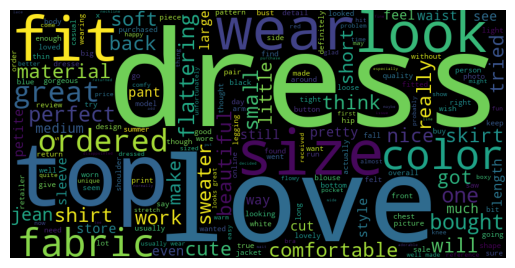

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["Review Text"].dropna())

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# Bigger words = appear more frequently in reviews
# Smaller words = appear less frequently in reviews in dataset

Most Popular Clothing Categories

This shows which type of clothing customers review the most.

In [27]:
df['Class Name'].value_counts().head(10)

Class Name
Dresses       6145
Knits         4626
Blouses       2983
Sweaters      1380
Pants         1350
Jeans         1104
Fine gauge    1059
Skirts         903
Jackets        683
Lounge         669
Name: count, dtype: int64

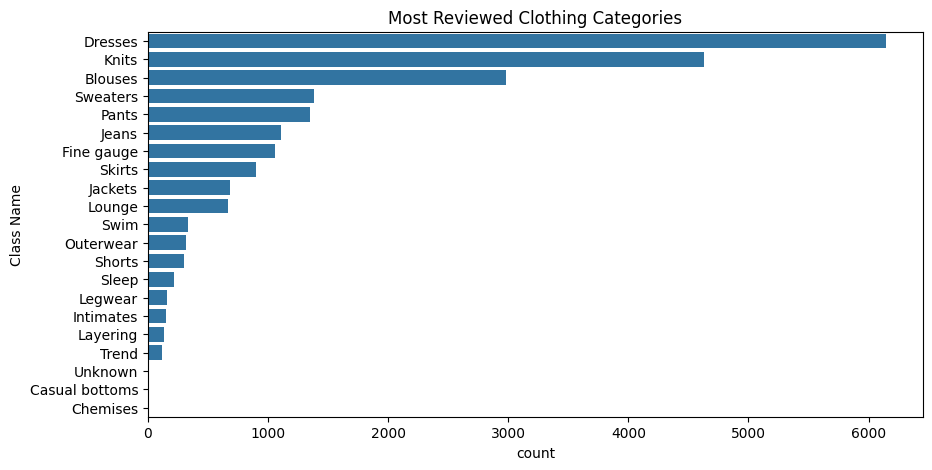

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(data=df, y='Class Name', order=df['Class Name'].value_counts().index)
plt.title("Most Reviewed Clothing Categories")
plt.show()


Rating Distribution (Customer Satisfaction)

In [29]:
df['Rating'].value_counts()

Rating
5    12540
4     4908
3     2823
2     1549
1      821
Name: count, dtype: int64

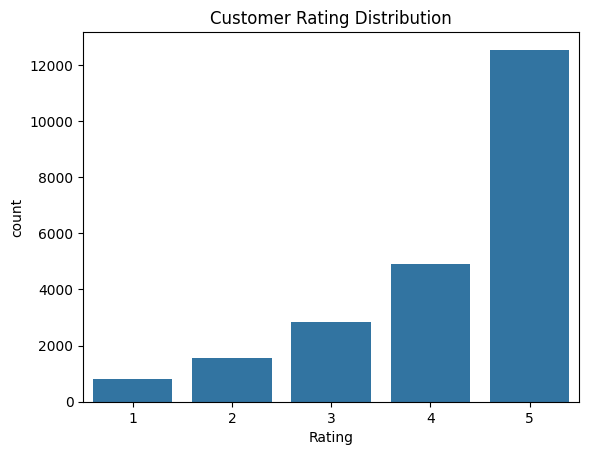

In [30]:
sns.countplot(x='Rating', data=df)
plt.title("Customer Rating Distribution")
plt.show()

Sentiment by Clothing Category

This analysis shows customer satisfaction per category.

In [31]:
pd.crosstab(df['Class Name'], df['Sentiment'])

Sentiment,Negative,Positive
Class Name,,
Blouses,157,2826
Casual bottoms,0,1
Chemises,0,1
Dresses,390,5755
Fine gauge,63,996
Intimates,8,139
Jackets,49,634
Jeans,59,1045
Knits,285,4341


In [32]:
 # Age Group vs Rating
 
pd.crosstab(df['Age Group'], df['Rating'])

Rating,1,2,3,4,5
Age Group,,,,,
18-25,34,59,137,257,696
26-35,208,438,773,1154,2920
36-45,244,484,914,1585,3866
46-60,248,436,752,1445,3603
60+,87,132,247,465,1453


In [33]:
pd.crosstab(df["Age Group"], df["Department Name"])                       #Popular category by age

Department Name,Bottoms,Dresses,Intimate,Jackets,Tops,Trend,Unknown
Age Group,,,,,,,
18-25,174,349,114,50,484,10,2
26-35,838,1674,496,246,2219,18,2
36-45,1246,1946,478,283,3091,44,5
46-60,1062,1630,418,282,3055,33,4
60+,341,544,147,141,1198,13,0


In [34]:
# Best clothing categories
df.groupby("Class Name")["Rating"].mean().sort_values(ascending=False)

Class Name
Unknown           5.000000
Layering          4.348485
Jeans             4.347826
Lounge            4.301943
Sleep             4.294393
Jackets           4.288433
Intimates         4.278912
Pants             4.261481
Shorts            4.253289
Legwear           4.246835
Fine gauge        4.237960
Skirts            4.229236
Outerwear         4.181818
Swim              4.171687
Sweaters          4.168841
Knits             4.145698
Blouses           4.142809
Dresses           4.138812
Chemises          4.000000
Casual bottoms    4.000000
Trend             3.838983
Name: Rating, dtype: float64

In [37]:
df.groupby("Department Name")["Rating"].mean().sort_values(ascending=False)

Department Name
Unknown     5.000000
Bottoms     4.278809
Intimate    4.271022
Jackets     4.254491
Tops        4.157743
Dresses     4.138812
Trend       3.838983
Name: Rating, dtype: float64

In [36]:
df.groupby("Department Name")["Rating"].mean().sort_values(ascending=False)

Department Name
Unknown     5.000000
Bottoms     4.278809
Intimate    4.271022
Jackets     4.254491
Tops        4.157743
Dresses     4.138812
Trend       3.838983
Name: Rating, dtype: float64

In [41]:
import os
print(os.listdir())

['data_cleaning.ipynb']


In [42]:
df = pd.read_csv("../data/womens_clothing_reviews.csv")

In [46]:
df.to_csv("../data/cleaned_fashion_data.csv", index=False)

In [2]:
pip install plotly  wordcloud prophet

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install requests beautifulsoup4 prophet scikit-learn


   -------------------- ------------------- 1/2 [beautifulsoup4]
   ---------------------------------------- 2/2 [beautifulsoup4]

Note: you may need to restart the kernel to use updated packages.
